# **Introduction to Neural Networks with Keras**

_All credits to Aurelien Geron, adapted from his book "Hands-on Machine Learning"_

<center><img src="./figs/keras.png" width="540" height="240"></center>

- Keras is a high-level Deep Learning API that allows building, training and executing all sorts of NNs.
    - Its evaluation relies on a compuation backend!
- Most popular open source DL libraries:
    - **TensorFlow**: Based on python, made by Google
    - **Microsoft Cognitive Toolkit (CNTK)**: Based on C++
    - **Theano** (University of Montreal): Based on python, not in development any more, but still very popular

- We will focus on the TF implementation of the Keras API (tf.keras). Multimultibackend also possible!
   
    <center><img src="image2.jpg" width="740" height="440"></center>

- A very popular alternative to Keras/TensorFlow is **PyTorch**
    - Developed by Facebook
    - API similar to Keras

  <center><img src="https://miro.medium.com/max/1200/1*4br4WmxNo0jkcsY796jGDQ.jpeg" width=460 height=60 />  </center>

## Setup

First, let's import a few common modules, ensure MatplotLib plots figures inline and prepare a function to save the figures. We also check that Python 3.5 or later is installed, as well as Scikit-Learn ≥0.20 and TensorFlow ≥2.0.

In [1]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

try:
    # %tensorflow_version only exists in Colab.
    %tensorflow_version 2.x
except Exception:
    pass

# TensorFlow ≥2.0 is required
import tensorflow as tf
print(dir(tf))
#assert tf.__version__ >= "2.0"

# Common imports
import numpy as np
import os

['AggregationMethod', 'Assert', 'CriticalSection', 'DType', 'DeviceSpec', 'GradientTape', 'Graph', 'IndexedSlices', 'IndexedSlicesSpec', 'Module', 'Operation', 'OptionalSpec', 'RaggedTensor', 'RaggedTensorSpec', 'RegisterGradient', 'SparseTensor', 'SparseTensorSpec', 'Tensor', 'TensorArray', 'TensorArraySpec', 'TensorShape', 'TensorSpec', 'TypeSpec', 'UnconnectedGradients', 'Variable', 'VariableAggregation', 'VariableSynchronization', '_API_MODULE', '_LazyLoader', '__all__', '__builtins__', '__cached__', '__compiler_version__', '__cxx11_abi_flag__', '__doc__', '__file__', '__git_version__', '__internal__', '__loader__', '__monolithic_build__', '__name__', '__operators__', '__package__', '__path__', '__spec__', '__version__', '_absolute_import', '_api', '_compat', '_current_file_location', '_current_module', '_distutils', '_division', '_estimator_module', '_fi', '_inspect', '_ll', '_logging', '_main_dir', '_major_api_version', '_module_dir', '_module_util', '_names_with_underscore', '_o

In [2]:
# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
def image_path(fig_id):
    return "images/"+fig_id

def save_fig(fig_id, tight_layout=True):
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(image_path(fig_id) + ".png", format='png', dpi=300)

## Building an Image Classifier

In [3]:
# First let's import TensorFlow and Keras.

import tensorflow as tf
from tensorflow import keras

print(tf.__version__)
print(keras.__version__)

2.4.1
2.4.0


Let's start by loading the fashion MNIST dataset. Keras has a number of functions to load popular datasets in `keras.datasets`. The dataset is already split for you between a training set and a test set, but it can be useful to split the training set further to have a validation set:

In [4]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

# The training set contains 60,000 grayscale images, each 28x28 pixels:
print(X_train_full.shape)

# Each pixel intensity is represented as a byte (0 to 255):
print(X_train_full.dtype)

(60000, 28, 28)
uint8


In [5]:
#Let's split the full training set into a validation set and a (smaller) training set. 
# We also scale the pixel intensities down to the 0-1 range and convert them to floats,
# by dividing by 255.

X_valid, X_train = X_train_full[:5000] / 255., X_train_full[5000:] / 255.
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test / 255.

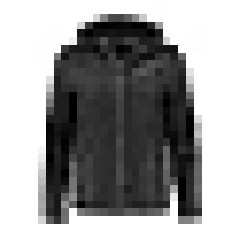

In [6]:
#You can plot an image using Matplotlib's `imshow()` function, 
# with a "binary" color map:

plt.imshow(X_train[0], cmap="binary")
plt.axis('off')
plt.show()

In [7]:
# The labels are the class IDs (represented as uint8), from 0 to 9:
print(y_train)

# Here are the corresponding class names:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]


# So the first image in the training set is a coat:
print(class_names[y_train[0]])

[4 0 7 ... 3 0 5]
Coat


In [8]:
# The validation set contains 5,000 images, and the test set contains 10,000 images:

print(X_valid.shape)
print(X_test.shape)

(5000, 28, 28)
(10000, 28, 28)


Saving figure fashion_mnist_plot


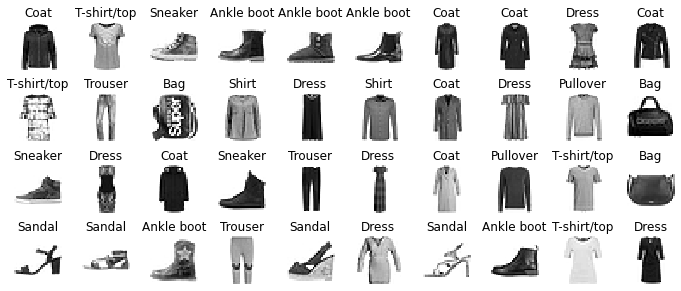

In [9]:
# Let's take a look at a sample of the images in the dataset:
n_rows = 4
n_cols = 10
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(X_train[index], cmap="binary", interpolation="nearest")
        plt.axis('off')
        plt.title(class_names[y_train[index]], fontsize=12)
plt.subplots_adjust(wspace=0.2, hspace=0.5)
save_fig('fashion_mnist_plot', tight_layout=False)
plt.show()

In [10]:
## This is how a simple DNN in Keras would look like! 
## Layers with N neurons and activation functions
model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28, 28]))
model.add(keras.layers.Dense(300, activation="relu"))
model.add(keras.layers.Dense(100, activation="relu"))
model.add(keras.layers.Dense(10, activation="softmax"))

## Activation functions

In [11]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def derivative(f, z, eps=0.000001):
    return (f(z + eps) - f(z - eps))/(2 * eps)

Saving figure activation_functions_plot


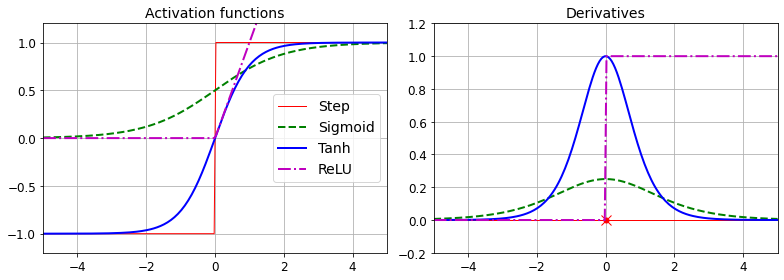

In [12]:
z = np.linspace(-5, 5, 200)

plt.figure(figsize=(11,4))

plt.subplot(121)
plt.plot(z, np.sign(z), "r-", linewidth=1, label="Step")
plt.plot(z, sigmoid(z), "g--", linewidth=2, label="Sigmoid")
plt.plot(z, np.tanh(z), "b-", linewidth=2, label="Tanh")
plt.plot(z, relu(z), "m-.", linewidth=2, label="ReLU")
plt.grid(True)
plt.legend(loc="center right", fontsize=14)
plt.title("Activation functions", fontsize=14)
plt.axis([-5, 5, -1.2, 1.2])

plt.subplot(122)
plt.plot(z, derivative(np.sign, z), "r-", linewidth=1, label="Step")
plt.plot(0, 0, "ro", markersize=5)
plt.plot(0, 0, "rx", markersize=10)
plt.plot(z, derivative(sigmoid, z), "g--", linewidth=2, label="Sigmoid")
plt.plot(z, derivative(np.tanh, z), "b-", linewidth=2, label="Tanh")
plt.plot(z, derivative(relu, z), "m-.", linewidth=2, label="ReLU")
plt.grid(True)
#plt.legend(loc="center right", fontsize=14)
plt.title("Derivatives", fontsize=14)
plt.axis([-5, 5, -0.2, 1.2])
figname = "activation_functions_plot"
save_fig(figname)
plt.show()

<center><img src="images/activation_functions_plot.png" width=800" height="440"></center>

## Sequential model

In [13]:
## these lines are for reproducibility and to clear any remains from previous networks!
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [14]:
model = keras.models.Sequential([
    ## computes X.reshape(-1, 1), simple preprocessing. Argument: shape of instances
    keras.layers.Flatten(input_shape=[28, 28]),
    ## dense layers: each of the 300 neurons connected to every input
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    ## output with neuron per class (10). Softmax activation function
    ## (because the classes are exclusive).
    keras.layers.Dense(10, activation="softmax")
])

print(model.layers)

[<tensorflow.python.keras.layers.core.Flatten object at 0x131158890>, <tensorflow.python.keras.layers.core.Dense object at 0x131267d50>, <tensorflow.python.keras.layers.core.Dense object at 0x131272950>, <tensorflow.python.keras.layers.core.Dense object at 0x131255b50>]


In [15]:
model.summary()
## plenty of parameters!
## e.g. first layer: 784 × 300 connection weights, plus 300 bias terms
## 'None' means that batch size can be anything

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten (Flatten)            (None, 784)               0         
_________________________________________________________________
dense (Dense)                (None, 300)               235500    
_________________________________________________________________
dense_1 (Dense)              (None, 100)               30100     
_________________________________________________________________
dense_2 (Dense)              (None, 10)                1010      
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
_________________________________________________________________


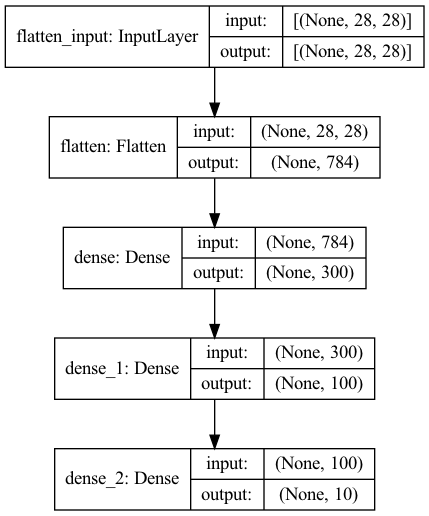

In [16]:
keras.utils.plot_model(model, "my_fashion_mnist_model.png", show_shapes=True)

In [17]:
## initialized the connection weights randomly (important)
hidden1 = model.layers[1]
weights, biases = hidden1.get_weights()
print(weights)

[[ 0.02448617 -0.00877795 -0.02189048 ... -0.02766046  0.03859074
  -0.06889391]
 [ 0.00476504 -0.03105379 -0.0586676  ...  0.00602964 -0.02763776
  -0.04165364]
 [-0.06189284 -0.06901957  0.07102345 ... -0.04238207  0.07121518
  -0.07331658]
 ...
 [-0.03048757  0.02155137 -0.05400612 ... -0.00113463  0.00228987
   0.05581069]
 [ 0.07061854 -0.06960931  0.07038955 ... -0.00384101  0.00034875
   0.02878492]
 [-0.06022581  0.01577859 -0.02585464 ... -0.00527829  0.00272203
  -0.06793761]]


In [18]:
print(weights.shape)
print(biases)
print(biases.shape)

(784, 300)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
(300,)


In [19]:
## specify the loss function and the optimizer to use. 
## Possible specify a list of extra metrics to compute during
## training and evaluation:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

In [20]:
## This is equivalent to:
model.compile(loss=keras.losses.sparse_categorical_crossentropy,
              optimizer=keras.optimizers.SGD(),
              metrics=[keras.metrics.sparse_categorical_accuracy])

- "sparse_categorical_cross entropy" loss because of sparse labels 
    - for each instance there is just a target class index and the classes are exclusive
    - If one target probability per class for each instance (à la soft-voting) "categorical_crossentropy" loss
    - For binary classification, use "sigmoid" (i.e., logistic) activation function in the output layer instead of the "softmax" activation function, and we would use the "binary_crossentropy" loss.

- For the optimizer, "sgd" means that we will train the model using simple Stochastic Gradient Descent. Keras will perform the backpropagation algorithm (i.e., reverse-mode autodiff plus Gradient Descent)
- Finally, useful to measure its "accuracy" during training and evaluation.

In [21]:
## finally, fit the data (first time data enters in the code)
#We also pass a validation set (this is optional). 
#Useful to measure the loss and the extra metrics on this set at the end of each epoch,
history = model.fit(X_train, y_train, epochs=30,
                    validation_data=(X_valid, y_valid))

Epoch 1/30
1719/1719 [==============================] - 13s 7ms/step - loss: 1.0187 - sparse_categorical_accuracy: 0.6805 - val_loss: 0.5213 - val_sparse_categorical_accuracy: 0.8226
Epoch 2/30
1719/1719 [==============================] - 11s 6ms/step - loss: 0.5028 - sparse_categorical_accuracy: 0.8262 - val_loss: 0.4350 - val_sparse_categorical_accuracy: 0.8536
Epoch 3/30
1719/1719 [==============================] - 10s 6ms/step - loss: 0.4485 - sparse_categorical_accuracy: 0.8423 - val_loss: 0.5355 - val_sparse_categorical_accuracy: 0.7970
Epoch 4/30
1719/1719 [==============================] - 12s 7ms/step - loss: 0.4209 - sparse_categorical_accuracy: 0.8530 - val_loss: 0.3919 - val_sparse_categorical_accuracy: 0.8650
Epoch 5/30
1719/1719 [==============================] - 13s 7ms/step - loss: 0.4060 - sparse_categorical_accuracy: 0.8586 - val_loss: 0.3741 - val_sparse_categorical_accuracy: 0.8686
Epoch 6/30
1719/1719 [==============================] - 12s 7ms/step - loss: 0.3752 -

In [22]:
## history contains the training parameters (history.params), 
## list of epochs it went through (history.epoch), and a dictionary 
## (history.history) containing the loss and extra metrics it measured 
## at the end of each epoch on the training and on the validation sets
print(history.params)
print(history.epoch)
history.history.keys()

{'verbose': 1, 'epochs': 30, 'steps': 1719}
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]


dict_keys(['loss', 'sparse_categorical_accuracy', 'val_loss', 'val_sparse_categorical_accuracy'])

Saving figure keras_learning_curves_plot


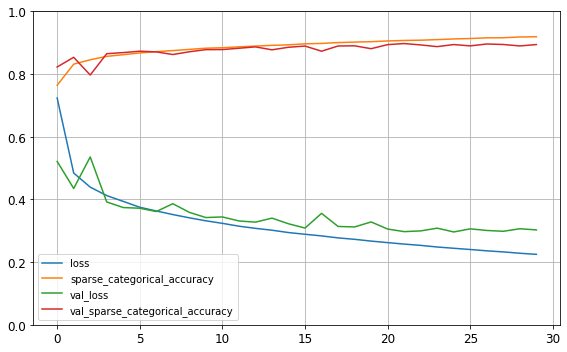

In [23]:
import pandas as pd

pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
save_fig("keras_learning_curves_plot")
plt.show()

In [24]:
## if needed, we could continue training
## Keras will retake it from where it left it!
model.evaluate(X_test, y_test)

313/313 [==============================] - 2s 6ms/step - loss: 0.3372 - sparse_categorical_accuracy: 0.8825


[0.33723148703575134, 0.8824999928474426]

In [25]:
## now we can predict on new instances!
X_new = X_test[:3]
y_proba = model.predict(X_new)
y_proba.round(2)

array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.01, 0.  , 0.03, 0.  , 0.96],
       [0.  , 0.  , 0.98, 0.  , 0.02, 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]],
      dtype=float32)

In [26]:
# and see which are the most likely classes
y_pred = np.argmax(model.predict(X_new), axis=-1)
print(y_pred)
print(np.array(class_names)[y_pred])
y_new = y_test[:3]
print(y_new)

[9 2 1]
['Ankle boot' 'Pullover' 'Trouser']
[9 2 1]


Saving figure fashion_mnist_images_plot


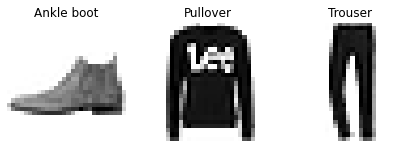

In [27]:
plt.figure(figsize=(7.2, 2.4))
for index, image in enumerate(X_new):
    plt.subplot(1, 3, index + 1)
    plt.imshow(image, cmap="binary", interpolation="nearest")
    plt.axis('off')
    plt.title(class_names[y_test[index]], fontsize=12)
plt.subplots_adjust(wspace=0.2, hspace=0.5)
save_fig('fashion_mnist_images_plot', tight_layout=False)
plt.show()

## Regression MLP

In [28]:
## California housing dataset
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()

X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

In [29]:
## same as before
np.random.seed(42)
tf.random.set_seed(42)
## note different loss function!
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=X_train.shape[1:]),
    ## output layer with single neuron
    keras.layers.Dense(1)
])
## lr is the learning rate (tunable)
model.compile(loss="mean_squared_error", optimizer=keras.optimizers.SGD(lr=1e-3))

In [30]:
## same as before...
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid))
mse_test = model.evaluate(X_test, y_test)
X_new = X_test[:3]
y_pred = model.predict(X_new)
print(y_pred)

Epoch 1/20
363/363 [==============================] - 3s 5ms/step - loss: 2.2656 - val_loss: 0.8560
Epoch 2/20
363/363 [==============================] - 2s 6ms/step - loss: 0.7413 - val_loss: 0.6531
Epoch 3/20
363/363 [==============================] - 2s 6ms/step - loss: 0.6604 - val_loss: 0.6099
Epoch 4/20
363/363 [==============================] - 2s 5ms/step - loss: 0.6245 - val_loss: 0.5658
Epoch 5/20
363/363 [==============================] - 2s 4ms/step - loss: 0.5770 - val_loss: 0.5355
Epoch 6/20
363/363 [==============================] - 2s 4ms/step - loss: 0.5609 - val_loss: 0.5173
Epoch 7/20
363/363 [==============================] - 1s 3ms/step - loss: 0.5500 - val_loss: 0.5081
Epoch 8/20
363/363 [==============================] - 1s 3ms/step - loss: 0.5200 - val_loss: 0.4799
Epoch 9/20
363/363 [==============================] - 1s 3ms/step - loss: 0.5051 - val_loss: 0.4690
Epoch 10/20
363/363 [==============================] - 1s 4ms/step - loss: 0.4910 - val_loss: 0.4656

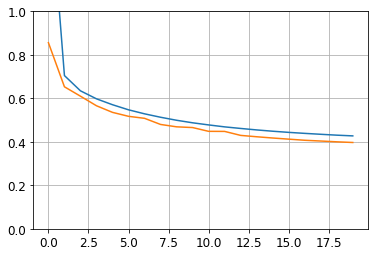

In [31]:
plt.plot(pd.DataFrame(history.history))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

## Functional API

- Not all neural network models are simply sequential. 
    - Wide & Deep neural network
 <center>
    <img src="net1.jpg" width=400>
</center>

In [32]:
np.random.seed(42)
tf.random.set_seed(42)
input_ = keras.layers.Input(shape=X_train.shape[1:])
## we create a Dense layer with 30 neurons, using the ReLU activation function.
## We call it like a function, passing it the input!
## This is why this is called the Functional API
hidden1 = keras.layers.Dense(30, activation="relu")(input_)
hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
##  Concatenate layer, immediately use it like a function, 
## concatenates the input and the output of the second hidden layer
concat = keras.layers.concatenate([input_, hidden2])
output = keras.layers.Dense(1)(concat)
## finally create the model
model = keras.models.Model(inputs=[input_], outputs=[output])

In [33]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 8)]          0                                            
__________________________________________________________________________________________________
dense_5 (Dense)                 (None, 30)           270         input_1[0][0]                    
__________________________________________________________________________________________________
dense_6 (Dense)                 (None, 30)           930         dense_5[0][0]                    
__________________________________________________________________________________________________
concatenate (Concatenate)       (None, 38)           0           input_1[0][0]                    
                                                                 dense_6[0][0]                

In [34]:
model.compile(loss="mean_squared_error", optimizer=keras.optimizers.SGD(lr=1e-3))
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))
mse_test = model.evaluate(X_test, y_test)
y_pred = model.predict(X_new)

Epoch 1/20
363/363 [==============================] - 7s 11ms/step - loss: 1.9731 - val_loss: 3.3940
Epoch 2/20
363/363 [==============================] - 3s 9ms/step - loss: 0.7638 - val_loss: 0.9360
Epoch 3/20
363/363 [==============================] - 3s 8ms/step - loss: 0.6045 - val_loss: 0.5649
Epoch 4/20
363/363 [==============================] - 1s 4ms/step - loss: 0.5862 - val_loss: 0.5712
Epoch 5/20
363/363 [==============================] - 1s 4ms/step - loss: 0.5452 - val_loss: 0.5045
Epoch 6/20
363/363 [==============================] - 2s 5ms/step - loss: 0.5243 - val_loss: 0.4831
Epoch 7/20
363/363 [==============================] - 1s 3ms/step - loss: 0.5185 - val_loss: 0.4639
Epoch 8/20
363/363 [==============================] - 1s 3ms/step - loss: 0.4947 - val_loss: 0.4638
Epoch 9/20
363/363 [==============================] - 2s 5ms/step - loss: 0.4782 - val_loss: 0.4421
Epoch 10/20
363/363 [==============================] - 1s 3ms/step - loss: 0.4708 - val_loss: 0.431

- Also possible to send different subsets of input features through the wide or deep paths.
    - Send different features through both paths
 <center>
    <img src="net2.jpg" width=400>
</center>

In [35]:
## Send 5 features (features 0 to 4), and 6 through the deep path (features 2 to 7).
## Note that 3 features will go through both (features 2, 3 and 4).

np.random.seed(42)
tf.random.set_seed(42)
input_A = keras.layers.Input(shape=[5], name="wide_input")
input_B = keras.layers.Input(shape=[6], name="deep_input")
hidden1 = keras.layers.Dense(30, activation="relu")(input_B)
hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
## very similar to before!
concat = keras.layers.concatenate([input_A, hidden2])
output = keras.layers.Dense(1, name="output")(concat)
## must specify that we now have two outputs...
model = keras.models.Model(inputs=[input_A, input_B], outputs=[output])

In [36]:
## compile the model
model.compile(loss="mse", optimizer=keras.optimizers.SGD(lr=1e-3))

## prepare the data (note we split the inputs)
X_train_A, X_train_B = X_train[:, :5], X_train[:, 2:]
X_valid_A, X_valid_B = X_valid[:, :5], X_valid[:, 2:]
X_test_A, X_test_B = X_test[:, :5], X_test[:, 2:]
X_new_A, X_new_B = X_test_A[:3], X_test_B[:3]

## fit, evaluate and predict
## we've got now two input sets for train, valid and test!
history = model.fit((X_train_A, X_train_B), y_train, epochs=20,
                    validation_data=((X_valid_A, X_valid_B), y_valid))
mse_test = model.evaluate((X_test_A, X_test_B), y_test)
y_pred = model.predict((X_new_A, X_new_B))

Epoch 1/20
363/363 [==============================] - 3s 5ms/step - loss: 3.1941 - val_loss: 0.8072
Epoch 2/20
363/363 [==============================] - 2s 5ms/step - loss: 0.7247 - val_loss: 0.6658
Epoch 3/20
363/363 [==============================] - 2s 5ms/step - loss: 0.6176 - val_loss: 0.5687
Epoch 4/20
363/363 [==============================] - 2s 5ms/step - loss: 0.5799 - val_loss: 0.5296
Epoch 5/20
363/363 [==============================] - 3s 9ms/step - loss: 0.5409 - val_loss: 0.4993
Epoch 6/20
363/363 [==============================] - 2s 7ms/step - loss: 0.5173 - val_loss: 0.4811
Epoch 7/20
363/363 [==============================] - 4s 10ms/step - loss: 0.5186 - val_loss: 0.4696
Epoch 8/20
363/363 [==============================] - 3s 8ms/step - loss: 0.4977 - val_loss: 0.4496
Epoch 9/20
363/363 [==============================] - 1s 3ms/step - loss: 0.4765 - val_loss: 0.4404
Epoch 10/20
363/363 [==============================] - 2s 4ms/step - loss: 0.4676 - val_loss: 0.431

- Yet another alternative, adding additional outputs
    - Requried by task, e.g., locate and classify the main object in a picture
    - Multiple independent tasks based on the same data, e.g., multitask classification (happy or not, man or woman)
    - Regularization: Auxiliary outputs to ensure that the underlying part of the network learns something useful on its own

 <center>
    <img src="net3.jpg" width=400>
</center>

In [37]:
np.random.seed(42)
tf.random.set_seed(42)
input_A = keras.layers.Input(shape=[5], name="wide_input")
input_B = keras.layers.Input(shape=[6], name="deep_input")
hidden1 = keras.layers.Dense(30, activation="relu")(input_B)
hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
concat = keras.layers.concatenate([input_A, hidden2])
output = keras.layers.Dense(1, name="main_output")(concat)
## design the additional output, specify it in the model
aux_output = keras.layers.Dense(1, name="aux_output")(hidden2)
model = keras.models.Model(inputs=[input_A, input_B],
                           outputs=[output, aux_output])

In [38]:
## Each output will need its own loss function! Pass a list of losses
## Keras will compute all these losses and simply add them up to get the final loss
## Possible to set all the loss weights when compiling the model:
model.compile(loss=["mse", "mse"], loss_weights=[0.9, 0.1], optimizer=keras.optimizers.SGD(lr=1e-3))

In [39]:
## We need to provide labels for each output. 
## Here, the main and auxiliary outputs predict the same thing.
## Just use the same labels!
history = model.fit([X_train_A, X_train_B], [y_train, y_train], epochs=20,
                    validation_data=([X_valid_A, X_valid_B], [y_valid, y_valid]))

Epoch 1/20
363/363 [==============================] - 3s 4ms/step - loss: 3.4633 - main_output_loss: 3.3289 - aux_output_loss: 4.6732 - val_loss: 1.6233 - val_main_output_loss: 0.8468 - val_aux_output_loss: 8.6117
Epoch 2/20
363/363 [==============================] - 2s 5ms/step - loss: 0.9807 - main_output_loss: 0.7503 - aux_output_loss: 3.0537 - val_loss: 1.5163 - val_main_output_loss: 0.6836 - val_aux_output_loss: 9.0109
Epoch 3/20
363/363 [==============================] - 1s 4ms/step - loss: 0.7742 - main_output_loss: 0.6290 - aux_output_loss: 2.0810 - val_loss: 1.4639 - val_main_output_loss: 0.6229 - val_aux_output_loss: 9.0326
Epoch 4/20
363/363 [==============================] - 2s 5ms/step - loss: 0.6952 - main_output_loss: 0.5897 - aux_output_loss: 1.6449 - val_loss: 1.3388 - val_main_output_loss: 0.5481 - val_aux_output_loss: 8.4552
Epoch 5/20
363/363 [==============================] - 1s 2ms/step - loss: 0.6469 - main_output_loss: 0.5508 - aux_output_loss: 1.5118 - val_loss

In [40]:
## when evaluating, will get all the losses
total_loss, main_loss, aux_loss = model.evaluate(
    [X_test_A, X_test_B], [y_test, y_test])
## the same when predicting..
y_pred_main, y_pred_aux = model.predict([X_new_A, X_new_B])

162/162 [==============================] - 0s 2ms/step - loss: 0.4668 - main_output_loss: 0.4178 - aux_output_loss: 0.9082


## Saving and Restoring

In [41]:
np.random.seed(42)
tf.random.set_seed(42)
## we create a simple model to be saved
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=[8]),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(1)
])  
model.compile(loss="mse", optimizer=keras.optimizers.SGD(lr=1e-3))
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid))
mse_test = model.evaluate(X_test, y_test)

Epoch 1/10
363/363 [==============================] - 2s 3ms/step - loss: 3.3697 - val_loss: 0.7126
Epoch 2/10
363/363 [==============================] - 1s 3ms/step - loss: 0.6964 - val_loss: 0.6880
Epoch 3/10
363/363 [==============================] - 2s 5ms/step - loss: 0.6167 - val_loss: 0.5803
Epoch 4/10
363/363 [==============================] - 1s 2ms/step - loss: 0.5846 - val_loss: 0.5166
Epoch 5/10
363/363 [==============================] - 1s 2ms/step - loss: 0.5321 - val_loss: 0.4895
Epoch 6/10
363/363 [==============================] - 2s 7ms/step - loss: 0.5083 - val_loss: 0.4951
Epoch 7/10
363/363 [==============================] - 3s 7ms/step - loss: 0.5044 - val_loss: 0.4861
Epoch 8/10
363/363 [==============================] - 1s 4ms/step - loss: 0.4813 - val_loss: 0.4554
Epoch 9/10
363/363 [==============================] - 1s 3ms/step - loss: 0.4627 - val_loss: 0.4413
Epoch 10/10
162/162 [==============================] - 0s 1ms/step - loss: 0.4382


In [42]:
## save both the model’s architecture (including every layer’s hyperparameters) 
## and the values of all the model parameters for every layer
## (e.g., connection weights and biases).
## It also saves the optimizer (including its hyperparameters
## and any state it may have).
model.save("my_keras_model.h5")
model = keras.models.load_model("my_keras_model.h5")
model.predict(X_new)

array([[0.5400236],
       [1.6505969],
       [3.0098243]], dtype=float32)

## Using Callbacks during Training

- The fit() method accepts a callbacks argument: specify a list of objects that Keras will call at the start and end of training, at the start and end of each epoch, and even before and after processing each batch. Examples
    - ModelCheckpoint: to save model when performance on the validation set is the best 
    - EarlyStopping: interrupt training when it measures no progress on the validation set for a number of epochs
    - TensorBoard: needed to run the TensorBoard interactive visualization tool

In [43]:
## create a simple model to play with
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=[8]),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(1)
])    

In [44]:
## run and specify the callback
model.compile(loss="mse", optimizer=keras.optimizers.SGD(lr=1e-3))
## save_best_only=True: only saves model when its performance on the validation set 
## is the best so far. Never train for too long and overfit the training set: 
## simply restore the last model saved after training
checkpoint_cb = keras.callbacks.ModelCheckpoint("my_keras_model.h5", save_best_only=True)
history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid),
                    callbacks=[checkpoint_cb])
model = keras.models.load_model("my_keras_model.h5") # rollback to best model (useful if
## computer crashes!)
mse_test = model.evaluate(X_test, y_test)

Epoch 1/10
363/363 [==============================] - 4s 8ms/step - loss: 3.3697 - val_loss: 0.7126
Epoch 2/10
363/363 [==============================] - 1s 4ms/step - loss: 0.6964 - val_loss: 0.6880
Epoch 3/10
363/363 [==============================] - 1s 2ms/step - loss: 0.6167 - val_loss: 0.5803
Epoch 4/10
363/363 [==============================] - 1s 3ms/step - loss: 0.5846 - val_loss: 0.5166
Epoch 5/10
363/363 [==============================] - 3s 8ms/step - loss: 0.5321 - val_loss: 0.4895
Epoch 6/10
363/363 [==============================] - 2s 4ms/step - loss: 0.5083 - val_loss: 0.4951
Epoch 7/10
363/363 [==============================] - 2s 5ms/step - loss: 0.5044 - val_loss: 0.4861
Epoch 8/10
363/363 [==============================] - 1s 4ms/step - loss: 0.4813 - val_loss: 0.4554
Epoch 9/10
363/363 [==============================] - 1s 3ms/step - loss: 0.4627 - val_loss: 0.4413
Epoch 10/10
162/162 [==============================] - 1s 3ms/step - loss: 0.4382


In [45]:
## Early stopping callback
## patience: number of epochs where with no progress on the validation set to stop
## Large number of epochs: automatic stop!
model.compile(loss="mse", optimizer=keras.optimizers.SGD(lr=1e-3))
early_stopping_cb = keras.callbacks.EarlyStopping(patience=10,
                                                  restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=100,
                    validation_data=(X_valid, y_valid),
                    callbacks=[checkpoint_cb, early_stopping_cb])
mse_test = model.evaluate(X_test, y_test)

Epoch 1/100
363/363 [==============================] - 3s 4ms/step - loss: 0.4578 - val_loss: 0.4110
Epoch 2/100
363/363 [==============================] - 1s 3ms/step - loss: 0.4430 - val_loss: 0.4266
Epoch 3/100
363/363 [==============================] - 2s 5ms/step - loss: 0.4376 - val_loss: 0.3996
Epoch 4/100
363/363 [==============================] - 1s 3ms/step - loss: 0.4361 - val_loss: 0.3939
Epoch 5/100
363/363 [==============================] - 1s 2ms/step - loss: 0.4204 - val_loss: 0.3889
Epoch 6/100
363/363 [==============================] - 1s 3ms/step - loss: 0.4112 - val_loss: 0.3866
Epoch 7/100
363/363 [==============================] - 2s 6ms/step - loss: 0.4226 - val_loss: 0.3860
Epoch 8/100
363/363 [==============================] - 3s 9ms/step - loss: 0.4135 - val_loss: 0.3793
Epoch 9/100
363/363 [==============================] - 1s 3ms/step - loss: 0.4039 - val_loss: 0.3746
Epoch 10/100
363/363 [==============================] - 2s 5ms/step - loss: 0.4023 - val_lo

## TensorBoard

- TensorBoard is an interactive visualization tool to e.g, 
    - view the learning curves during training and compare learning curves between multiple runs
    - visualize the computation graph, 
    - view images generated by model, 
    - visualize complex multidimensional data projected down to 3D and automatically clustered
- TensorBoard will create logs, need to specify folders to avoid overwriting them

In [46]:
## creates dirs to store logs
root_logdir = os.path.join(os.curdir, "my_logs")

def get_run_logdir():
    import time
    run_id = time.strftime("run_%Y_%m_%d-%H_%M_%S")
    return os.path.join(root_logdir, run_id)

run_logdir = get_run_logdir()
print(run_logdir)

./my_logs/run_2024_03_04-16_12_27


In [47]:
## create model to visualize
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=[8]),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(1)
])    
model.compile(loss="mse", optimizer=keras.optimizers.SGD(lr=1e-3))

In [48]:
## prepare TensorBoard callback, specifying route
tensorboard_cb = keras.callbacks.TensorBoard(run_logdir)
history = model.fit(X_train, y_train, epochs=30,
                    validation_data=(X_valid, y_valid),
                    callbacks=[checkpoint_cb, tensorboard_cb])

Epoch 1/30
363/363 [==============================] - 2s 4ms/step - loss: 3.3697 - val_loss: 0.7126
Epoch 2/30
363/363 [==============================] - 1s 4ms/step - loss: 0.6964 - val_loss: 0.6880
Epoch 3/30
363/363 [==============================] - 1s 2ms/step - loss: 0.6167 - val_loss: 0.5803
Epoch 4/30
363/363 [==============================] - 1s 3ms/step - loss: 0.5846 - val_loss: 0.5166
Epoch 5/30
363/363 [==============================] - 1s 3ms/step - loss: 0.5321 - val_loss: 0.4895
Epoch 6/30
363/363 [==============================] - 1s 3ms/step - loss: 0.5083 - val_loss: 0.4951
Epoch 7/30
363/363 [==============================] - 1s 3ms/step - loss: 0.5044 - val_loss: 0.4861
Epoch 8/30
363/363 [==============================] - 1s 2ms/step - loss: 0.4813 - val_loss: 0.4554
Epoch 9/30
363/363 [==============================] - 1s 3ms/step - loss: 0.4627 - val_loss: 0.4413
Epoch 10/30
363/363 [==============================] - 1s 4ms/step - loss: 0.4549 - val_loss: 0.4379

To start the TensorBoard server, one option is to open a terminal, if needed activate the virtualenv where you installed TensorBoard, go to this notebook's directory, then type:

```bash
$ tensorboard --logdir=./my_logs --port=6006
```

You can then open your web browser to [localhost:6006](http://localhost:6006) and use TensorBoard. Once you are done, press Ctrl-C in the terminal window, this will shutdown the TensorBoard server.

Alternatively, you can load TensorBoard's Jupyter extension and run it like this:
```
%load_ext tensorboard
%tensorboard --logdir=./my_logs --port=6006
```

## Hyperparameter Tuning

- Possible to create a wrapper of a Keras model to tune hyperparameters in sklearn!
    - Call GridSearchCV or RandomizedSearchCV
    - Very flexibility, but can be very slow...
    

In [50]:
## simple model to create a regressor
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

def build_model(n_hidden=1, n_neurons=30, learning_rate=3e-3, input_shape=[8]):
    model = keras.models.Sequential()
    model.add(keras.layers.InputLayer(input_shape=input_shape))
    for layer in range(n_hidden):
        model.add(keras.layers.Dense(n_neurons, activation="relu"))
    model.add(keras.layers.Dense(1))
    optimizer = keras.optimizers.SGD(lr=learning_rate)
    model.compile(loss="mse", optimizer=optimizer)
    return model

In [51]:
## now create the wrapper! Can be trained as another model
keras_reg = keras.wrappers.scikit_learn.KerasRegressor(build_model)
keras_reg.fit(X_train, y_train, epochs=100,
              validation_data=(X_valid, y_valid),
              callbacks=[keras.callbacks.EarlyStopping(patience=10)])

Epoch 1/100
363/363 [==============================] - 4s 6ms/step - loss: 1.5673 - val_loss: 20.7721
Epoch 2/100
363/363 [==============================] - 1s 2ms/step - loss: 1.3216 - val_loss: 5.0266
Epoch 3/100
363/363 [==============================] - 1s 2ms/step - loss: 0.5972 - val_loss: 0.5490
Epoch 4/100
363/363 [==============================] - 1s 2ms/step - loss: 0.4985 - val_loss: 0.4529
Epoch 5/100
363/363 [==============================] - 1s 2ms/step - loss: 0.4608 - val_loss: 0.4188
Epoch 6/100
363/363 [==============================] - 1s 2ms/step - loss: 0.4410 - val_loss: 0.4129
Epoch 7/100
363/363 [==============================] - 1s 2ms/step - loss: 0.4463 - val_loss: 0.4004
Epoch 8/100
363/363 [==============================] - 1s 4ms/step - loss: 0.4283 - val_loss: 0.3944
Epoch 9/100
363/363 [==============================] - 1s 3ms/step - loss: 0.4139 - val_loss: 0.3961
Epoch 10/100
363/363 [==============================] - 2s 5ms/step - loss: 0.4107 - val_l

In [52]:
## also applies to predict
mse_test = keras_reg.score(X_test, y_test)
y_pred = keras_reg.predict(X_new)

162/162 [==============================] - 3s 16ms/step - loss: 0.3409:


**Warning**: the following cell crashes at the end of training. This seems to be caused by [Keras issue #13586](https://github.com/keras-team/keras/issues/13586), which was triggered by a recent change in Scikit-Learn. [Pull Request #13598](https://github.com/keras-team/keras/pull/13598) seems to fix the issue, so this problem should be resolved soon. In the meantime, I've added `.tolist()` and `.rvs(1000).tolist()` as workarounds.

In [53]:
## now, one can use sklearn classes as usual

np.random.seed(42)
tf.random.set_seed(42)

from scipy.stats import reciprocal
from sklearn.model_selection import RandomizedSearchCV

param_distribs = {
    "n_hidden": [0, 1, 2, 3],
    "n_neurons": np.arange(1, 100)             .tolist(),
    "learning_rate": reciprocal(3e-4, 3e-2)    .rvs(1000).tolist(),
}

## fix needed here, see https://github.com/scikit-learn/scikit-learn/issues/15805#issuecomment-562927893
rnd_search_cv = RandomizedSearchCV(keras_reg, param_distribs, n_iter=10, cv=3, verbose=2)
rnd_search_cv.fit(X_train, y_train, epochs=10,
                  validation_data=(X_valid, y_valid),
                  callbacks=[keras.callbacks.EarlyStopping(patience=10)])

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Epoch 1/10
242/242 [==============================] - 3s 7ms/step - loss: 1.3827 - val_loss: 0.4703
Epoch 2/10
242/242 [==============================] - 1s 2ms/step - loss: 0.4880 - val_loss: 0.4247
Epoch 3/10
242/242 [==============================] - 2s 8ms/step - loss: 0.4541 - val_loss: 0.4052
Epoch 4/10
242/242 [==============================] - 3s 13ms/step - loss: 0.4518 - val_loss: 0.3975
Epoch 5/10
242/242 [==============================] - 3s 10ms/step - loss: 0.4337 - val_loss: 0.3991
Epoch 6/10
242/242 [==============================] - 2s 9ms/step - loss: 0.4263 - val_loss: 0.4031
Epoch 7/10
242/242 [==============================] - 1s 5ms/step - loss: 0.4385 - val_loss: 0.4043
Epoch 8/10
242/242 [==============================] - 1s 5ms/step - loss: 0.4301 - val_loss: 0.3929
Epoch 9/10
242/242 [==============================] - 1s 2ms/step - loss: 0.4108 - val_loss: 0.4040
Epoch 10/10
121/121 [================

Epoch 1/10
242/242 [==============================] - 1s 3ms/step - loss: 4.4546 - val_loss: 7.5238
Epoch 2/10
242/242 [==============================] - 0s 2ms/step - loss: 1.7950 - val_loss: 8.6120
Epoch 3/10
242/242 [==============================] - 1s 2ms/step - loss: 1.1115 - val_loss: 8.4896
Epoch 4/10
242/242 [==============================] - 0s 2ms/step - loss: 0.9287 - val_loss: 7.7423
Epoch 5/10
242/242 [==============================] - 0s 2ms/step - loss: 0.8253 - val_loss: 6.8202
Epoch 6/10
242/242 [==============================] - 0s 2ms/step - loss: 0.7837 - val_loss: 5.9344
Epoch 7/10
242/242 [==============================] - 1s 3ms/step - loss: 0.7711 - val_loss: 5.1492
Epoch 8/10
242/242 [==============================] - 0s 2ms/step - loss: 0.7292 - val_loss: 4.4548
Epoch 9/10
242/242 [==============================] - 1s 2ms/step - loss: 0.7279 - val_loss: 3.9122
Epoch 10/10
121/121 [==============================] - 0s 1ms/step - loss: 0.7600
[CV] END learning_

Epoch 1/10
242/242 [==============================] - 2s 6ms/step - loss: 1.9669 - val_loss: 307.7497
Epoch 2/10
242/242 [==============================] - 1s 4ms/step - loss: 1.0908 - val_loss: 76.3015
Epoch 3/10
242/242 [==============================] - 1s 4ms/step - loss: 0.8437 - val_loss: 795.2294
Epoch 4/10
242/242 [==============================] - 1s 2ms/step - loss: 41.8219 - val_loss: 704.0454
Epoch 5/10
242/242 [==============================] - 0s 2ms/step - loss: 1.0379 - val_loss: 2668.0312
Epoch 6/10
242/242 [==============================] - 1s 3ms/step - loss: 6.1716 - val_loss: 1446.2616
Epoch 7/10
242/242 [==============================] - 1s 5ms/step - loss: 3.3018 - val_loss: 1540.5388
Epoch 8/10
242/242 [==============================] - 1s 3ms/step - loss: 71.5701 - val_loss: 1396.7128
Epoch 9/10
242/242 [==============================] - 2s 7ms/step - loss: 6.0212 - val_loss: 1334.0870
Epoch 10/10
121/121 [==============================] - 0s 3ms/step - loss: 0

242/242 [==============================] - 1s 3ms/step - loss: 2.2993 - val_loss: 0.8898
Epoch 2/10
242/242 [==============================] - 1s 3ms/step - loss: 0.5586 - val_loss: 0.5270
Epoch 3/10
242/242 [==============================] - 1s 3ms/step - loss: 0.4526 - val_loss: 0.4844
Epoch 4/10
242/242 [==============================] - 1s 3ms/step - loss: 0.4289 - val_loss: 0.4250
Epoch 5/10
242/242 [==============================] - 1s 2ms/step - loss: 0.4117 - val_loss: 0.3735
Epoch 6/10
242/242 [==============================] - 1s 3ms/step - loss: 0.3892 - val_loss: 0.3859
Epoch 7/10
242/242 [==============================] - 1s 3ms/step - loss: 0.3723 - val_loss: 0.4576
Epoch 8/10
242/242 [==============================] - 1s 3ms/step - loss: 0.3751 - val_loss: 0.4928
Epoch 9/10
242/242 [==============================] - 1s 3ms/step - loss: 0.3636 - val_loss: 0.6246
Epoch 10/10
121/121 [==============================] - 0s 2ms/step - loss: 0.3695
[CV] END learning_rate=0.0045

RandomizedSearchCV(cv=3,
                   estimator=<tensorflow.python.keras.wrappers.scikit_learn.KerasRegressor object at 0x130765a90>,
                   param_distributions={'learning_rate': [0.001683454924600351,
                                                          0.02390836445593178,
                                                          0.008731907739399206,
                                                          0.004725396149933917,
                                                          0.0006154014789262348,
                                                          0.0006153331256530192,
                                                          0.0003920021771415983,
                                                          0.01619845322936229,
                                                          0.004779156784872302,
                                                          0.0078...
                                                          0.00502142573

In [54]:
## we treat the model as any other in sklearn
print(rnd_search_cv.best_params_)
print(rnd_search_cv.best_score_)
print(rnd_search_cv.best_estimator_)
rnd_search_cv.score(X_test, y_test)

model = rnd_search_cv.best_estimator_.model
print(model)
model.evaluate(X_test, y_test)

{'n_neurons': 80, 'n_hidden': 3, 'learning_rate': 0.0059640580092043885}
-0.35029828548431396
162/162 [==============================] - 0s 2ms/step - loss: 0.3370


0.336996465921402